In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, precision_recall_curve, roc_curve, auc

from utils.model_utils import validate, train, evaluate, get_tensor_dataset, get_data_loader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")
val_df = pd.read_csv("data/val.csv")

In [3]:
label = 'label'

train_dataset = get_tensor_dataset(train_df, label)
test_dataset = get_tensor_dataset(test_df, label)
val_dataset = get_tensor_dataset(val_df, label)

print(train_dataset)
print(test_dataset)
print(val_dataset)

In [4]:
BATCH_SIZE = 32
train_loader = get_data_loader(train_dataset, BATCH_SIZE)
test_loader = get_data_loader(test_dataset, BATCH_SIZE)
val_loader = get_data_loader(val_dataset, BATCH_SIZE)

In [5]:
model = nn.Sequential(
    nn.Linear(1024, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.4),

    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(64, 1)
)
model.to(device)
print(model)

Sequential(
  (0): Linear(in_features=1024, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=256, out_features=64, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.3, inplace=False)
  (7): Linear(in_features=64, out_features=1, bias=True)
)


In [6]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5)
THRESHOLD = 0.5

In [7]:
best_loss = float('inf')
patience = 10
counter = 0

for epoch in range(50):
    print("Epoch:", epoch)
    train(
        model=model,
        loss_function=criterion,
        threshold=THRESHOLD,
        optimizer=optimizer,
        train_loader=train_loader,
        device=device
    )
    val_loss = validate(
        model=model,
        loss_function=criterion,
        threshold=THRESHOLD,
        val_loader=val_loader,
        device=device
    )
    print("-" * 40)

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "../model_repository/pneumonia_model_phase_2_.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

Epoch: 0
Train - Loss: 0.6832 Accuracy: 0.5634
Valid - Loss: 0.6693 Accuracy: 0.6627
----------------------------------------
Epoch: 1
Train - Loss: 0.6616 Accuracy: 0.6187
Valid - Loss: 0.6454 Accuracy: 0.7108
----------------------------------------
Epoch: 2
Train - Loss: 0.6409 Accuracy: 0.6637
Valid - Loss: 0.6264 Accuracy: 0.7367
----------------------------------------
Epoch: 3
Train - Loss: 0.6210 Accuracy: 0.6980
Valid - Loss: 0.6070 Accuracy: 0.7470
----------------------------------------
Epoch: 4
Train - Loss: 0.6078 Accuracy: 0.7069
Valid - Loss: 0.5959 Accuracy: 0.7556
----------------------------------------
Epoch: 5
Train - Loss: 0.5950 Accuracy: 0.7223
Valid - Loss: 0.5852 Accuracy: 0.7642
----------------------------------------
Epoch: 6
Train - Loss: 0.5872 Accuracy: 0.7341
Valid - Loss: 0.5753 Accuracy: 0.7676
----------------------------------------
Epoch: 7
Train - Loss: 0.5770 Accuracy: 0.7356
Valid - Loss: 0.5679 Accuracy: 0.7762
---------------------------------

===== EVALUATION METRICS =====
Accuracy  : 0.7680
Precision : 0.7248
Recall    : 0.5347
F1 Score  : 0.6154

Confusion Matrix:
 [[339  41]
 [ 94 108]]

Detailed Classification Report:

              precision    recall  f1-score   support

         0.0       0.78      0.89      0.83       380
         1.0       0.72      0.53      0.62       202

    accuracy                           0.77       582
   macro avg       0.75      0.71      0.72       582
weighted avg       0.76      0.77      0.76       582



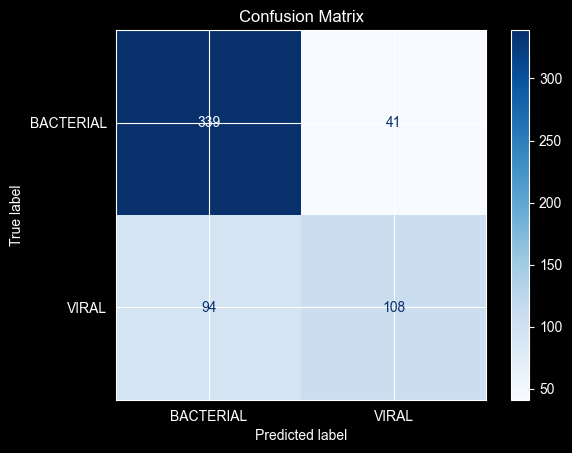

In [8]:
evaluate(model=model,
         threshold=THRESHOLD,
         data_loader=test_loader,
         device=device,
         labels=["BACTERIAL", "VIRAL"])

In [9]:
model.load_state_dict(torch.load("../model_repository/pneumonia_model_phase_2.pth"))
all_probs = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch).squeeze()
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
j_scores = tpr - fpr
best_threshold = roc_thresholds[np.argmax(j_scores)]

print("Chosen threshold:", best_threshold)

Chosen threshold: 0.35500735


===== EVALUATION METRICS =====
Accuracy  : 0.7715
Precision : 0.6635
Recall    : 0.6931
F1 Score  : 0.6780

Confusion Matrix:
 [[309  71]
 [ 62 140]]

Detailed Classification Report:

              precision    recall  f1-score   support

         0.0       0.83      0.81      0.82       380
         1.0       0.66      0.69      0.68       202

    accuracy                           0.77       582
   macro avg       0.75      0.75      0.75       582
weighted avg       0.77      0.77      0.77       582



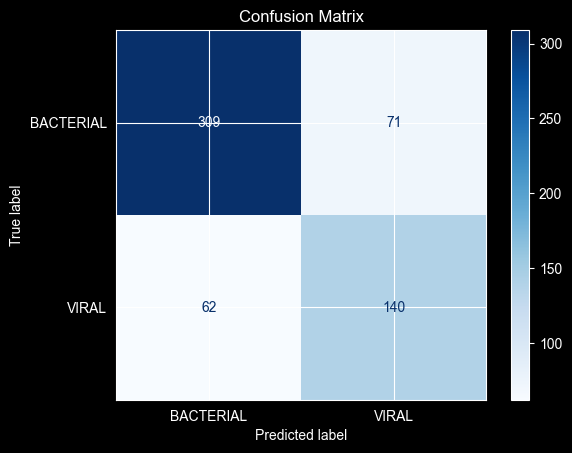

In [10]:
evaluate(model=model,
         threshold=best_threshold,
         data_loader=test_loader,
         device=device,
         labels=["BACTERIAL", "VIRAL"])

Best Threshold: 0.35500735
AUC: 0.8191697797748111


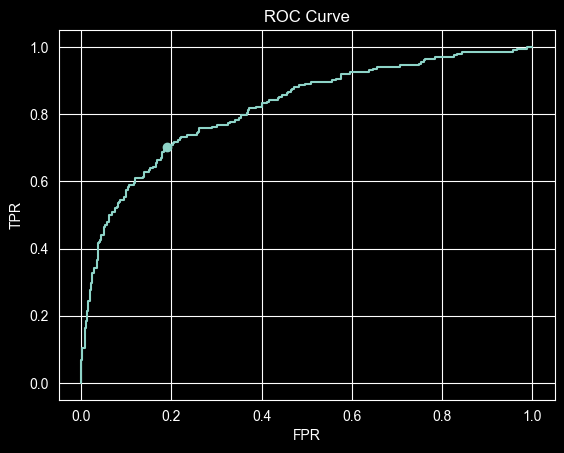

In [11]:
from matplotlib import pyplot as plt

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

# Best threshold (Youden J)
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("AUC:", roc_auc)

# Plot
plt.plot(fpr, tpr)
plt.scatter(fpr[best_idx], tpr[best_idx])  # best point
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()